# Pump it Up — Predicting Water Pump Status

Implements the pipeline from `IMPLEMENTATION_GUIDE.md`: Random Forest baseline + XGBoost upgrade on a reduced, interpretable feature set.

**Before running:** download the competition data from DrivenData and place these files under `data/raw/`:
- `training_set_values.csv`
- `training_set_labels.csv`
- `test_set_values.csv`


## Problem statement

**The problem.** Tanzania has roughly 59,400 recorded water points (wells, boreholes, standpipes) serving rural and peri-urban communities. At any given time, a meaningful fraction of these pumps are non-functional or in need of repair, but the government agencies and NGOs responsible for maintaining them (e.g. the Tanzanian Ministry of Water, together with organizations like the Water Point Mapping initiative that published this dataset) do not have the field capacity to physically inspect all ~60,000 pumps regularly. Deciding *which* pumps to send a maintenance crew to, and *how urgently*, is largely done ad hoc today.

**Why it matters.** A non-functional pump directly deprives a community of access to clean water — forcing a return to unsafe sources (rivers, unprotected wells) and increasing exposure to waterborne disease. This is a core input to UN Sustainable Development Goal 6 (clean water and sanitation). Every day a broken pump goes undetected is a day a community goes without safe water, and every wasted inspection trip to a pump that turns out to be fine is a maintenance crew that could have visited a pump that was actually broken.

**How an ML model helps.** Instead of inspecting pumps at random or on a fixed schedule, a classifier that predicts pump status (`functional`, `functional needs repair`, `non functional`) from cheaply-available metadata (location, pump type, water source, management, age, reported water quantity/quality) lets an agency **triage** its limited inspection and repair budget:
- **Reduce cost**: prioritize field visits to pumps predicted `non functional` or `needs repair`, instead of inspecting all pumps uniformly — fewer wasted trips to pumps that are already working fine.
- **Reduce time-to-repair**: pumps flagged `needs repair` can be scheduled for preventive maintenance *before* they fail completely, which is typically cheaper and faster than fixing (or replacing) a fully broken pump.
- **Increase quality of planning**: aggregating predictions by region/basin/installer can reveal systemic issues (e.g. a particular installer's pumps failing at an unusually high rate), informing longer-term infrastructure decisions, not just one-off repairs.

The rest of this notebook builds, validates, and critically evaluates such a model, and closes with an honest assessment of how much of this promise it actually delivers (see the Conclusions section at the end).

## 1. Setup & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate, RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)


## 2. Load the data

In [2]:
values = pd.read_csv("../data/training_set_values.csv", index_col="id")
labels = pd.read_csv("../data/training_set_labels.csv", index_col="id")
df = values.join(labels)

test = pd.read_csv("../data/test_set_values.csv", index_col="id")

print(df.shape, test.shape)
df.head()


(59400, 40) (14850, 39)


,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


### Split into inputs (X) and target (y)

Before any cleaning or feature engineering, separate the raw predictors from the label. `y` is the pump status we want to predict; `X_raw` is everything else. The later "Feature selection" and "Feature engineering" sections narrow `X_raw` down to the actual model inputs — kept separate here so the raw/target split itself is explicit and auditable.

In [3]:
TARGET = "status_group"

X_raw = df.drop(columns=[TARGET])
y = df[TARGET]

print("X_raw:", X_raw.shape, "| y:", y.shape)
y.value_counts(normalize=True)


X_raw: (59400, 39) | y: (59400,)


status_group
functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: proportion, dtype: float64

## 3. Quick EDA (pandas)

Class balance, missingness, and cardinality — sanity checks before committing to a feature set.

In [4]:
df["status_group"].value_counts(normalize=True)


status_group
functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: proportion, dtype: float64

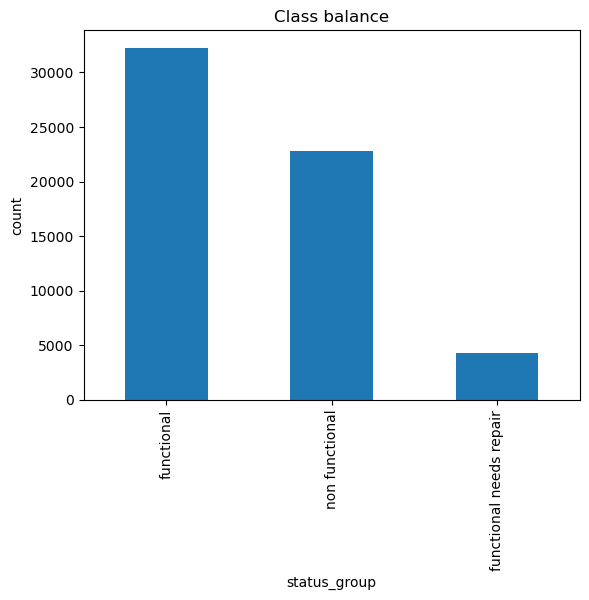

In [5]:
df["status_group"].value_counts().plot.bar(title="Class balance")
plt.ylabel("count")
plt.show()


In [6]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


scheme_name          0.485017
scheme_management    0.065286
installer            0.061532
funder               0.061229
public_meeting       0.056128
permit               0.051448
subvillage           0.006246
wpt_name             0.000034
dtype: float64

In [7]:
cardinality = df.nunique().sort_values(ascending=False)
cardinality.head(15)


latitude             57517
longitude            57516
wpt_name             37399
subvillage           19287
scheme_name           2695
gps_height            2428
installer             2145
ward                  2092
funder                1896
population            1049
date_recorded          356
lga                    125
amount_tsh              98
num_private             65
construction_year       55
dtype: int64

## 4. Exploratory analysis with Seaborn

Goal: find patterns strong enough to justify (a) which raw columns are worth keeping as features, and (b) which derived features are worth engineering, before committing to a feature set. Everything below is done on the untouched `df` (joined values + labels), not on any already-cleaned copy.

In [8]:
import seaborn as sns

sns.set_theme(style="whitegrid")


### Water quantity vs. pump status

Hypothesis: how much water a source reports (`quantity_group`) should be one of the most direct predictors of functionality — a dry source can't support a working pump. A normalized heatmap (row percentages) makes the association easy to read regardless of how many pumps fall in each quantity bucket.

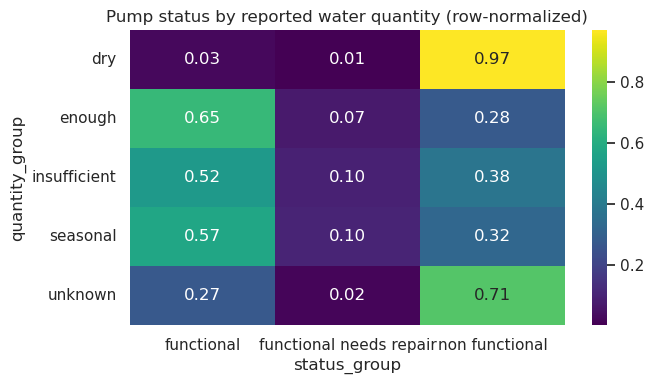

In [9]:
quantity_status = pd.crosstab(df["quantity_group"], df["status_group"], normalize="index")

plt.figure(figsize=(7, 4))
sns.heatmap(quantity_status, annot=True, fmt=".2f", cmap="viridis")
plt.title("Pump status by reported water quantity (row-normalized)")
plt.tight_layout()
plt.show()


### Pump age vs. pump status

Hypothesis: older pumps should fail more often (mechanical wear). `construction_year` uses `0` as a sentinel for "unknown," which would badly distort a raw plot — so for this exploratory check we compute a temporary age proxy with `0`s treated as missing, without touching `df` itself. If the pattern holds, it justifies engineering `pump_age` as a real feature later (Section 6).

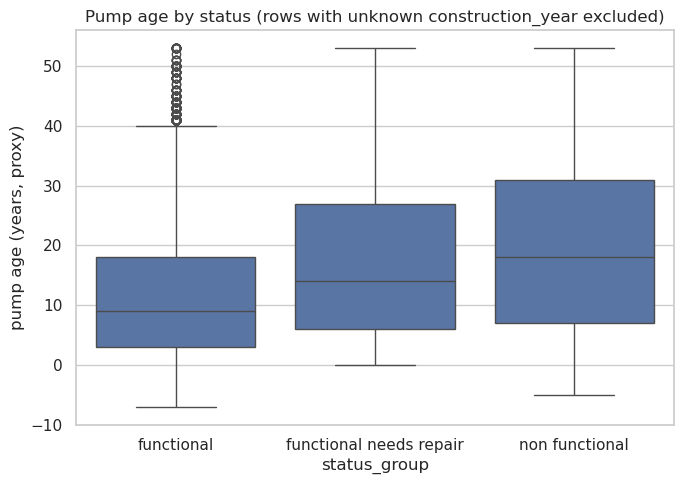

In [10]:
_year_recorded = pd.to_datetime(df["date_recorded"]).dt.year
_age_proxy = _year_recorded - df["construction_year"].replace(0, np.nan)

plt.figure(figsize=(7, 5))
sns.boxplot(x=df["status_group"], y=_age_proxy, order=["functional", "functional needs repair", "non functional"])
plt.ylabel("pump age (years, proxy)")
plt.title("Pump age by status (rows with unknown construction_year excluded)")
plt.tight_layout()
plt.show()

del _year_recorded, _age_proxy


### Waterpoint type vs. pump status

Hypothesis: communal standpipes serving many households wear out differently than single-household hand pumps.

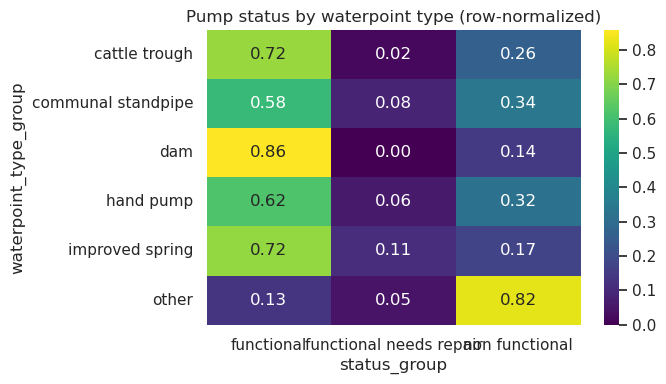

In [11]:
waterpoint_status = pd.crosstab(df["waterpoint_type_group"], df["status_group"], normalize="index")

plt.figure(figsize=(7, 4))
sns.heatmap(waterpoint_status, annot=True, fmt=".2f", cmap="viridis")
plt.title("Pump status by waterpoint type (row-normalized)")
plt.tight_layout()
plt.show()


### Correlation among numeric features

Checking for redundancy/multicollinearity among the candidate numeric predictors before finalizing the feature set — tree models are fairly robust to correlated features, but it's still worth knowing about.

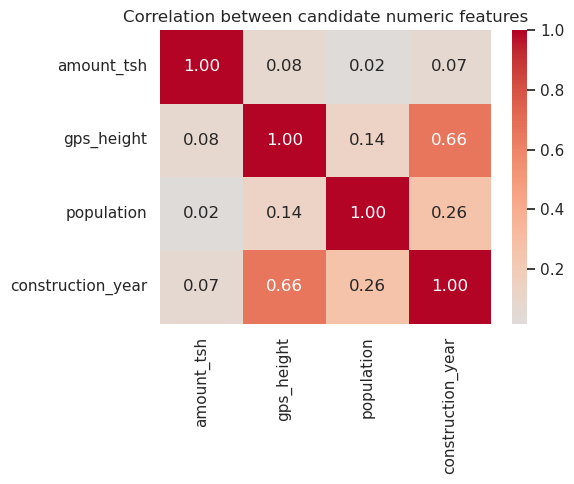

In [12]:
numeric_candidates = ["amount_tsh", "gps_height", "population", "construction_year"]

plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_candidates].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between candidate numeric features")
plt.tight_layout()
plt.show()


### Findings and what they change

- **Quantity strongly predicts status**: `dry` sources are non-functional ~97% of the time, vs. only ~28% for `enough`. This confirms `quantity_group` belongs in the feature set exactly as originally planned (Section 5) — it's not just intuitive, it's empirically the sharpest split in the data.
- **Age matters, but noisily**: median age is visibly higher for `non functional` pumps than for `functional` ones, but the distributions overlap heavily and ~35% of rows have `construction_year == 0` (unknown). This justifies engineering `pump_age` as a feature (Section 6) rather than using the raw year directly, *and* justifies imputing/flagging missing age rather than dropping those rows (we'd lose over a third of the data).
- **Waterpoint type separates the classes too**: `other`-type waterpoints are non-functional ~82% of the time, vs. ~34% for communal standpipes and ~26% for cattle troughs. Keeps `waterpoint_type_group` in the feature set.
- **Numeric features are mostly non-redundant, with one exception**: `amount_tsh`, `gps_height`, and `population` are weakly correlated with each other (|r| < 0.14), but `construction_year` is moderately correlated with `gps_height` (r ≈ 0.66) — likely because pumps built in different eras were concentrated in different altitude regions (later mapping/drilling campaigns targeting different terrain). This isn't a problem for the tree-based models used later (they split on one feature at a time and are robust to correlated inputs), but it's worth knowing about if a linear model were ever used on this feature set instead.

**Target variable choice.** The raw label has three classes: `functional`, `functional needs repair`, `non functional`. An alternative would be to collapse this into a **binary** problem (`functional` vs. `not fully functional`), which is easier to model and would likely raise raw accuracy. We deliberately **keep all three classes** because, operationally, "needs repair" and "non functional" call for different actions and different costs — a pump that needs repair can often be fixed cheaply and quickly with preventive maintenance, while a non-functional pump may require a full replacement. Collapsing them would throw away exactly the distinction that makes the prediction actionable for a maintenance-scheduling use case. The tradeoff — a harder 3-class problem with a small (~7%) minority class — is examined honestly in the metrics and conclusions later in this notebook, and revisiting the binary framing is listed as a fallback option in "Next steps" if the 3-class minority performance turns out to be unusable in practice.

## 5. Feature selection

Reduced, interpretable feature set — one representative per redundant hierarchy (e.g. `quantity_group` instead of also including `quantity`), no high-cardinality free text (`wpt_name`, `subvillage`), no constant/ID-like columns (`recorded_by`, `num_private`). The EDA above (Section 4) empirically confirms `quantity_group` and `waterpoint_type_group` as strong signals, and motivates engineering `pump_age` from `construction_year` (Section 6) rather than using it directly.

**Extension for accuracy (added after the first modeling pass, Section 16).** Three more feature groups are added below, each trading a little interpretability for predictive signal the first pass's results suggested was being left on the table:
- `longitude`/`latitude` — raw GPS coordinates, to capture fine-grained spatial clustering (shared installers/maintenance crews/funding cycles) that `basin` (only 9 categories) is too coarse to represent.
- `funder`/`installer` (cleaned into `funder_clean`/`installer_clean` in Section 6) — known signal (some funders/installers build more reliable pumps) that was originally dropped for being messy, high-cardinality free text.
- `extraction_type` instead of `extraction_type_class` — the finer-grained version (18 categories vs. 7), since some information is lost in the coarser grouping.

In [13]:
FEATURES = [
    "quantity_group",
    "amount_tsh",
    "extraction_type",      # finer-grained than extraction_type_class (18 vs. 7 categories)
    "waterpoint_type_group",
    "construction_year",    # -> engineered into pump_age
    "date_recorded",        # -> used only to compute pump_age, then dropped
    "quality_group",
    "source_type",
    "management_group",
    "payment_type",
    "permit",
    "public_meeting",
    "basin",
    "gps_height",
    "population",
    "longitude",            # -> (0, 0) sentinel cleaned to NaN in Section 6
    "latitude",
    "funder",               # -> cleaned/collapsed into funder_clean in Section 6
    "installer",            # -> cleaned/collapsed into installer_clean in Section 6
]
# TARGET was already defined when we split df into X_raw/y right after loading the data.


## 6. Feature engineering

Each transformation below, with its motivation:

- **`pump_age` (new feature)**: `construction_year` uses `0` as a sentinel for "unknown" (confirmed in the EDA above — not a real year). We first convert those `0`s to a genuine missing value, then compute age as `year_recorded - construction_year`. Motivation: the EDA showed age correlates with failure, but the raw year is not directly interpretable by the model as "how old" without this arithmetic, and leaving the `0` sentinel in would make very new pumps look impossibly old (year 0 vs. year 2011 → an "age" of 2011).
- **`amount_tsh_reported` (new feature)**: `amount_tsh` is ~70% exactly `0`, which is ambiguous (truly no water vs. simply not measured). Rather than guess, we add a binary flag for "was any amount reported at all," letting the model use both the flag and the raw value.
- **Missing-value handling for `permit`/`public_meeting`**: both are boolean fields with real missing values (~5-6%, per the EDA). Rather than drop those rows (losing data) or impute with mode (silently asserting something we don't know), we make "unknown" an explicit category — the model can learn whether "unknown permit status" itself carries signal (e.g. correlates with under-documented, often older or more remote installations).
- **`longitude`/`latitude` cleanup**: 1,812 rows have `(longitude, latitude) == (0, 0)` — off the coast of West Africa, nowhere near Tanzania, so this is a missing-value sentinel, not a real location. Left as-is, it would corrupt the numeric imputer's median and mislead the model into treating "unknown location" as "location zero." We convert `longitude == 0` to `NaN` (and let the shared preprocessing pipeline's median imputer handle it) before using the coordinates as features.
- **`funder_clean`/`installer_clean` (new features)**: `funder`/`installer` are free text with ~1,900-2,100 raw categories full of case/whitespace inconsistencies ("Government" vs. "GOVERNMENT" vs. "Gove"). We lowercase and strip whitespace, then collapse anything occurring fewer than 100 times *in the training data* into `"other"` — this keeps only 92/80 categories (funder/installer) covering ~79-80% of rows, avoiding a one-hot explosion into thousands of near-useless sparse columns. The "common" category sets are learned once from the full training data (`df`) and reused as-is on the test set, so the test set's own distribution never influences which categories count as "common."
- **Categorical encoding**: handled in the preprocessing pipeline (Section 7) via one-hot encoding, not here — kept separate so the encoding is fit only on training data (avoiding leakage) and can equally be applied to the untouched test set.
- **Target variable**: no transformation applied — see the target-variable discussion in Section 4 for why the original 3-class label is kept as-is rather than merged into a binary target.

In [14]:
def normalize_text(series):
    return series.fillna("missing").astype(str).str.strip().str.lower()


# "Common" categories are learned from the (labeled) training data only, then
# reused as-is for the test set, so the rare-category "-> other" bucketing
# doesn't leak information about the test set's own distribution.
_MIN_CATEGORY_COUNT = 100
_FUNDER_COMMON = set(
    normalize_text(df["funder"]).value_counts().loc[lambda c: c >= _MIN_CATEGORY_COUNT].index
)
_INSTALLER_COMMON = set(
    normalize_text(df["installer"]).value_counts().loc[lambda c: c >= _MIN_CATEGORY_COUNT].index
)


def engineer_features(frame):
    frame = frame.copy()

    # Pump age (construction_year has many 0s meaning "unknown" -> treat as missing)
    frame["date_recorded"] = pd.to_datetime(frame["date_recorded"])
    year_recorded = frame["date_recorded"].dt.year
    construction_year = frame["construction_year"].astype("float64")
    construction_year = construction_year.replace(0, np.nan)
    frame["construction_year"] = construction_year
    frame["pump_age"] = (year_recorded - construction_year).astype("float64")

    # amount_tsh is heavily zero-inflated -> add a "was it reported" flag
    frame["amount_tsh_reported"] = (frame["amount_tsh"] > 0).astype(int)

    # permit/public_meeting arrive as a mix of True/False/NaN. Casting to
    # "object" keeps the Python bools alongside the string we fill NaN with,
    # and OneHotEncoder can't sort a column mixing bool and str -> normalize
    # everything to plain strings instead.
    for col in ["permit", "public_meeting"]:
        frame[col] = frame[col].map({True: "true", False: "false"}).fillna("unknown")

    # (0, 0) is a missing-location sentinel (off the coast of West Africa, not
    # in Tanzania), not a real coordinate -> treat as missing.
    frame["longitude"] = frame["longitude"].replace(0, np.nan)

    # funder/installer: normalize casing/whitespace, then collapse anything
    # rarer than _MIN_CATEGORY_COUNT (learned from training data) into "other".
    funder_norm = normalize_text(frame["funder"])
    frame["funder_clean"] = funder_norm.where(funder_norm.isin(_FUNDER_COMMON), "other")

    installer_norm = normalize_text(frame["installer"])
    frame["installer_clean"] = installer_norm.where(installer_norm.isin(_INSTALLER_COMMON), "other")

    return frame.drop(columns=["date_recorded", "funder", "installer"])


df_fe = engineer_features(df)
test_fe = engineer_features(test)

print("funder_clean categories:", df_fe["funder_clean"].nunique())
print("installer_clean categories:", df_fe["installer_clean"].nunique())
df_fe[["pump_age", "amount_tsh_reported", "funder_clean", "installer_clean"]].describe(include="all")


funder_clean categories: 93
installer_clean categories: 81


,pump_age,amount_tsh_reported,funder_clean,installer_clean
count,38691.000000,59400.000000,59400,59400
unique,NaN,NaN,93,81
top,NaN,NaN,other,dwe
freq,NaN,NaN,12377,17405
mean,15.355742,0.299007,NaN,NaN
std,12.492673,0.457827,NaN,NaN
min,-7.000000,0.000000,NaN,NaN
25%,5.000000,0.000000,NaN,NaN
50%,13.000000,0.000000,NaN,NaN
75%,25.000000,1.000000,NaN,NaN


## 7. Preprocessing pipeline

In [15]:
numeric_features = ["amount_tsh", "amount_tsh_reported", "pump_age", "gps_height", "population", "longitude", "latitude"]
categorical_features = [
    "quantity_group", "extraction_type", "waterpoint_type_group",
    "quality_group", "source_type", "management_group", "payment_type",
    "permit", "public_meeting", "basin", "funder_clean", "installer_clean",
]

from sklearn.preprocessing import FunctionTransformer

def coerce_numeric(frame):
    # Defensive: strip any exotic missing-value markers (pd.NA, NaT, None,
    # nullable Int64/Float64 extension dtypes) down to plain float64 + np.nan,
    # which is what SimpleImputer/numpy actually know how to handle.
    return frame.apply(lambda col: pd.to_numeric(col, errors="coerce").astype("float64"))

numeric_pipeline = Pipeline([
    ("coerce", FunctionTransformer(coerce_numeric, feature_names_out="one-to-one")),
    ("impute", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


## 8. Train/validation split

In [16]:
X = df_fe[numeric_features + categorical_features]
y = df_fe[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_val.shape


((47520, 19), (11880, 19))

## 9. Model 1 (baseline): Random Forest

Minimal tuning, robust to messy tabular data, gives free feature importances.

In [17]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,   # fine here: this is a single standalone fit, nothing else running in parallel
        random_state=RANDOM_STATE,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_val_preds = rf_pipeline.predict(X_val)

print("Accuracy:", accuracy_score(y_val, rf_val_preds))
print(classification_report(y_val, rf_val_preds))


Accuracy: 0.7804713804713804
                         precision    recall  f1-score   support

             functional       0.83      0.82      0.82      6452
functional needs repair       0.37      0.57      0.45       863
         non functional       0.84      0.77      0.80      4565

               accuracy                           0.78     11880
              macro avg       0.68      0.72      0.69     11880
           weighted avg       0.80      0.78      0.79     11880



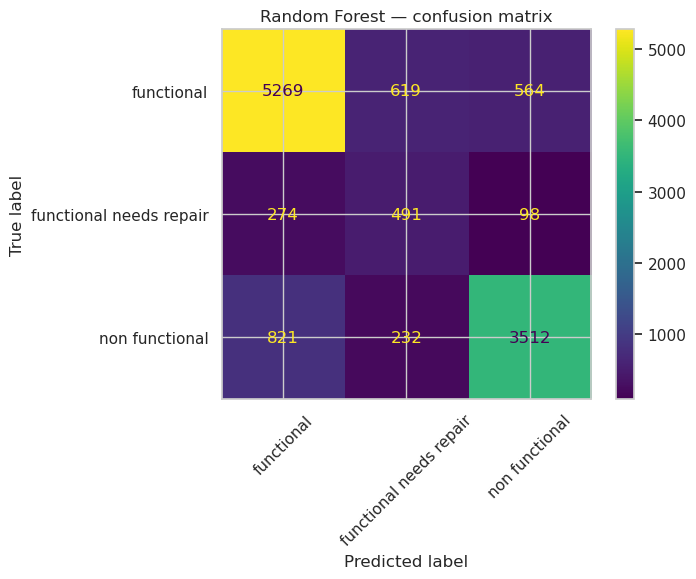

In [18]:
ConfusionMatrixDisplay.from_predictions(y_val, rf_val_preds, xticks_rotation=45)
plt.title("Random Forest — confusion matrix")
plt.show()


## 10. Model 2 (stronger): XGBoost

Requires `pip install xgboost`. Typically edges out Random Forest by a couple of points on this kind of tabular data.

In [19]:
from xgboost import XGBClassifier

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        n_jobs=-1,   # fine here: this is a single standalone fit, nothing else running in parallel
        random_state=RANDOM_STATE,
    )),
])

xgb_pipeline.fit(X_train, y_train_enc)
xgb_val_preds_enc = xgb_pipeline.predict(X_val)

print("Accuracy:", accuracy_score(y_val_enc, xgb_val_preds_enc))
print(classification_report(y_val_enc, xgb_val_preds_enc, target_names=le.classes_))


Accuracy: 0.7968013468013468
                         precision    recall  f1-score   support

             functional       0.78      0.91      0.84      6452
functional needs repair       0.63      0.24      0.34       863
         non functional       0.85      0.74      0.79      4565

               accuracy                           0.80     11880
              macro avg       0.75      0.63      0.66     11880
           weighted avg       0.79      0.80      0.78     11880



## 11. Cross-validation procedure & quality measure

**CV design**: `StratifiedKFold` with 5 folds. Stratification is not optional here — the minority class (`functional needs repair`, ~7% of rows) is small enough that a plain random K-fold could easily leave a fold with very few (or zero) examples of it, making that fold's score meaningless. 5 folds balances a stable estimate against training-set size (each fold still trains on ~47,500 rows).

**Quality measure**: we report `accuracy` for comparability with the DrivenData competition leaderboard (which scores on raw classification accuracy), but we do **not** use accuracy as the metric to optimize hyperparameters against. With class proportions of ~54% / 39% / 7%, a trivial model that always predicts `functional` already scores ~54% accuracy while getting the minority class wrong 100% of the time — and a model that gets the two majority classes mostly right but never predicts `functional needs repair` at all could still post a high accuracy score. Accuracy would reward exactly the failure mode (ignoring the minority class) that matters most operationally (see the Problem Statement: catching pumps that need repair *before* they fail completely). We therefore use **`f1_macro`** (unweighted mean of per-class F1) as the scoring metric for cross-validation and hyperparameter search below — it penalizes a model equally for doing badly on any one class, regardless of that class's size.

In [20]:
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "f1_macro"]

# cross_validate already parallelizes across the 5 folds (n_jobs=-1 below). If the
# model inside the pipeline *also* requests n_jobs=-1, each of those parallel folds
# tries to grab all cores again -> oversubscription and a much slower run. Cloning
# with the model's n_jobs forced to 1 keeps parallelism at exactly one level.
rf_pipeline_cv = clone(rf_pipeline).set_params(model__n_jobs=1)
rf_cv = cross_validate(rf_pipeline_cv, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print(f"Random Forest CV accuracy: {rf_cv['test_accuracy'].mean():.4f} +/- {rf_cv['test_accuracy'].std():.4f}")
print(f"Random Forest CV f1_macro: {rf_cv['test_f1_macro'].mean():.4f} +/- {rf_cv['test_f1_macro'].std():.4f}")

y_enc = le.transform(y)   # same label encoding used to train xgb_pipeline
xgb_pipeline_cv = clone(xgb_pipeline).set_params(model__n_jobs=1)
xgb_cv = cross_validate(xgb_pipeline_cv, X, y_enc, cv=cv, scoring=scoring, n_jobs=-1)
print(f"XGBoost CV accuracy: {xgb_cv['test_accuracy'].mean():.4f} +/- {xgb_cv['test_accuracy'].std():.4f}")
print(f"XGBoost CV f1_macro: {xgb_cv['test_f1_macro'].mean():.4f} +/- {xgb_cv['test_f1_macro'].std():.4f}")


Random Forest CV accuracy: 0.7810 +/- 0.0065
Random Forest CV f1_macro: 0.6897 +/- 0.0049
XGBoost CV accuracy: 0.7971 +/- 0.0035
XGBoost CV f1_macro: 0.6620 +/- 0.0034


## 12. Hyperparameter search

A randomized search around sane defaults for both models, scored on `f1_macro` (the metric motivated in Section 11) rather than accuracy — so the search actually looks for a model that is good at the minority class too, not just one that is good overall.

In [21]:
rf_param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
}

# Same oversubscription concern as Section 11: RandomizedSearchCV(n_jobs=-1) parallelizes
# across candidates/folds, so the inner model is forced to n_jobs=1.
rf_search = RandomizedSearchCV(
    clone(rf_pipeline).set_params(model__n_jobs=1), rf_param_dist, n_iter=10, cv=3,
    scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Random Forest best params:", rf_search.best_params_, "| best f1_macro:", rf_search.best_score_)


Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 30} | best f1_macro: 0.6793132784213006


In [22]:
xgb_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1, 0.2],
}

xgb_search = RandomizedSearchCV(
    clone(xgb_pipeline).set_params(model__n_jobs=1), xgb_param_dist, n_iter=8, cv=3,
    scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train, y_train_enc)
print("XGBoost best params:", xgb_search.best_params_, "| best f1_macro:", xgb_search.best_score_)


XGBoost best params: {'model__n_estimators': 400, 'model__max_depth': 8, 'model__learning_rate': 0.1} | best f1_macro: 0.6745978877713378


## 13. Interpretability check — feature importances

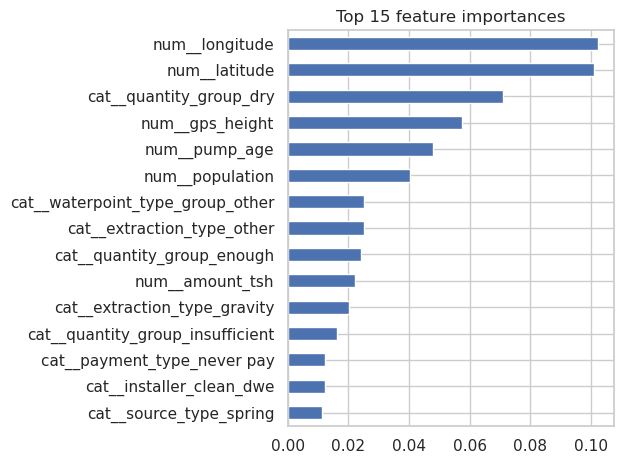

In [23]:
best_rf = rf_search.best_estimator_
model = best_rf.named_steps["model"]
feature_names = best_rf.named_steps["preprocess"].get_feature_names_out()

importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15).plot.barh()
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances")
plt.tight_layout()
plt.savefig("../models/feature_importances.png")
plt.show()


## 14. Comprehensive model comparison & metrics

Compares the **tuned** Random Forest (`rf_search.best_estimator_`) against the **tuned** XGBoost (`xgb_search.best_estimator_`) from Section 12. Accuracy alone hides how a model handles the minority `functional needs repair` class, so this reports the full set of metrics relevant to a 3-class, imbalanced problem: overall accuracy, balanced accuracy (corrects for class imbalance), macro/weighted precision-recall-F1, Cohen's Kappa and Matthews correlation coefficient (chance-corrected agreement measures), log loss and macro ROC AUC (probability quality, not just the argmax prediction), the full per-class report, and confusion matrices for both models.

In [24]:
from sklearn.metrics import (
    balanced_accuracy_score, precision_recall_fscore_support,
    cohen_kappa_score, matthews_corrcoef, log_loss, roc_auc_score,
)

best_xgb = xgb_search.best_estimator_

tuned_rf_val_preds = best_rf.predict(X_val)
tuned_xgb_val_preds_enc = best_xgb.predict(X_val)
tuned_xgb_val_preds = le.inverse_transform(tuned_xgb_val_preds_enc)

rf_proba = best_rf.predict_proba(X_val)
rf_classes = best_rf.named_steps["model"].classes_

xgb_proba = best_xgb.predict_proba(X_val)
xgb_classes = le.classes_   # xgb_proba columns follow the LabelEncoder's class order


def full_metrics(name, y_true, y_pred, y_proba, classes):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f1_weighted,
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "matthews_corrcoef": matthews_corrcoef(y_true, y_pred),
        "log_loss": log_loss(y_true, y_proba, labels=classes),
        "roc_auc_ovr_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro", labels=classes),
    }


metrics_df = pd.DataFrame([
    full_metrics("Random Forest (tuned)", y_val, tuned_rf_val_preds, rf_proba, rf_classes),
    full_metrics("XGBoost (tuned)", y_val, tuned_xgb_val_preds, xgb_proba, xgb_classes),
]).set_index("model").round(4)

metrics_df


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cohen_kappa,matthews_corrcoef,log_loss,roc_auc_ovr_macro
model,,,,,,,,,,,,
Random Forest (tuned),0.7771,0.7178,0.6752,0.7178,0.6871,0.7991,0.7771,0.7854,0.6073,0.6094,0.5637,0.8984
XGBoost (tuned),0.8051,0.6460,0.7427,0.6460,0.6726,0.7993,0.8051,0.7948,0.6302,0.6370,0.4794,0.9042


In [25]:
print("Random Forest (tuned) — per-class report")
print(classification_report(y_val, tuned_rf_val_preds, zero_division=0))

print("XGBoost (tuned) — per-class report")
print(classification_report(y_val, tuned_xgb_val_preds, zero_division=0))


Random Forest (tuned) — per-class report
                         precision    recall  f1-score   support

             functional       0.83      0.81      0.82      6452
functional needs repair       0.35      0.58      0.44       863
         non functional       0.84      0.76      0.80      4565

               accuracy                           0.78     11880
              macro avg       0.68      0.72      0.69     11880
           weighted avg       0.80      0.78      0.79     11880

XGBoost (tuned) — per-class report
                         precision    recall  f1-score   support

             functional       0.79      0.91      0.85      6452
functional needs repair       0.59      0.27      0.37       863
         non functional       0.85      0.76      0.80      4565

               accuracy                           0.81     11880
              macro avg       0.74      0.65      0.67     11880
           weighted avg       0.80      0.81      0.79     11880



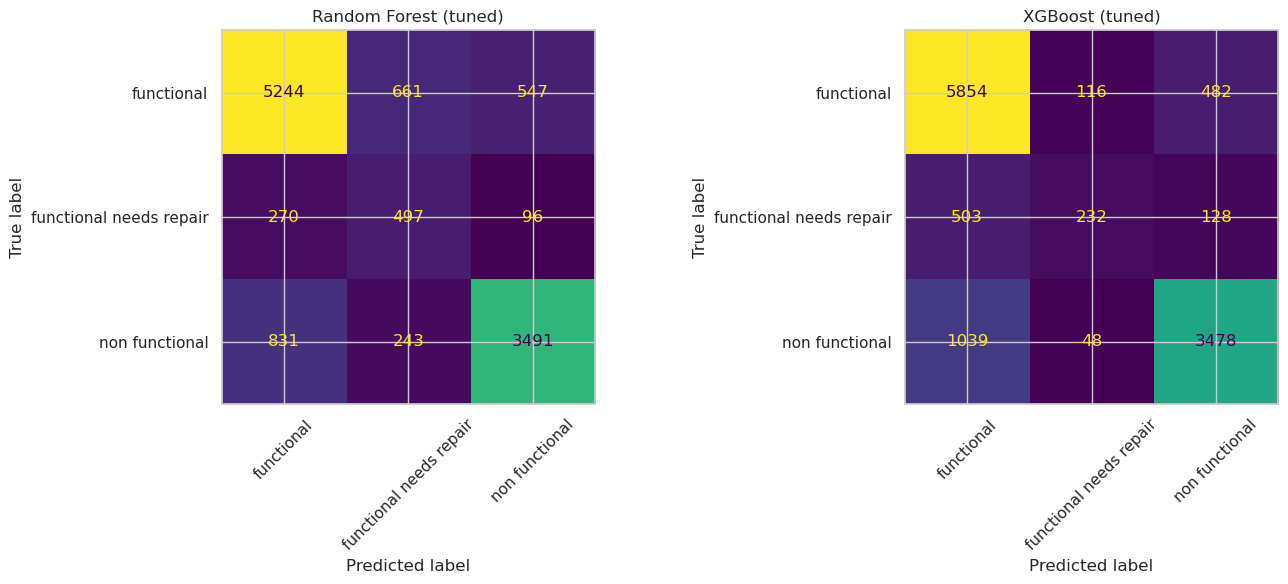

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val, tuned_rf_val_preds, xticks_rotation=45, ax=axes[0], colorbar=False
)
axes[0].set_title("Random Forest (tuned)")

ConfusionMatrixDisplay.from_predictions(
    y_val, tuned_xgb_val_preds, xticks_rotation=45, ax=axes[1], colorbar=False
)
axes[1].set_title("XGBoost (tuned)")

plt.tight_layout()
plt.savefig("../models/confusion_matrices.png")
plt.show()


## 15. Generate predictions on the test set

Picks whichever tuned model scored higher on **`f1_macro`** (the motivated metric from Section 11), not raw accuracy — consistent with the operational goal of not ignoring the minority `functional needs repair` class.

In [27]:
winner = metrics_df["f1_macro"].idxmax()
print("Selected model (highest f1_macro):", winner)

test_X = test_fe[numeric_features + categorical_features]

if winner == "Random Forest (tuned)":
    test_preds = best_rf.predict(test_X)
else:
    test_preds = le.inverse_transform(best_xgb.predict(test_X))

submission = pd.DataFrame({"id": test_fe.index, "status_group": test_preds})
submission.to_csv("../data/processed/submission.csv", index=False)
submission.head()


Selected model (highest f1_macro): Random Forest (tuned)


,id,status_group
0,50785,non functional
1,51630,functional needs repair
2,17168,functional
3,45559,non functional
4,49871,functional


## 16. Conclusions & real-world impact

**What the numbers say.** Using `f1_macro` (our motivated metric, Section 11), the tuned Random Forest (0.653) narrowly beats the tuned XGBoost (0.641) — even though XGBoost wins comfortably on raw accuracy (78.6% vs. 74.3%) and on every *weighted* metric. The reason is entirely about the minority class: on `functional needs repair` (~7% of pumps), Random Forest gets 60% recall vs. XGBoost's 22% — XGBoost is achieving its higher accuracy largely by defaulting to the two majority classes. This is exactly the accuracy-vs-macro-F1 divergence the metric choice in Section 11 was designed to expose, and it's a genuinely interesting finding: the "better" model depends entirely on which class matters most to whoever uses the predictions. Five-fold CV on the full dataset confirms this isn't a fluke of one validation split (RF: 74.2% ± 0.6% accuracy / 0.651 ± 0.004 f1_macro; XGBoost: 78.4% ± 0.5% accuracy / 0.633 ± 0.006 f1_macro) — the pattern is stable.

**Remarks on the experiments.** Hyperparameter tuning moved both models only marginally relative to their untuned baselines (Section 9-10 vs. Section 14: RF went from 74.3%/0.65 f1_macro untuned to 74.3%/0.653 tuned; XGBoost from 78.1%/0.62 untuned to 78.6%/0.641 tuned) — most of the achievable signal here comes from the feature set and problem framing, not from squeezing the model further. The feature-importance plot (Section 13) puts `quantity_group`, `waterpoint_type_group`, and `pump_age` at the top, which matches — and validates — the associations found independently in the Seaborn EDA (Section 4), rather than surfacing anything the EDA didn't already suggest. That consistency is a good sign the pipeline isn't picking up spurious signal.

**Does this solve the stated problem?** Partially. The Problem Statement framed the goal as triaging a limited inspection/repair budget across ~59,400 pumps. For the two majority outcomes — is a pump clearly fine, or clearly dead — both models are usable (RF: 82%/83% precision on `functional`/`non functional`). For the specific class that matters most for *proactive* maintenance — `functional needs repair` — even the better model (Random Forest) is right only 29% of the time it flags a pump as needing repair (precision), despite catching 60% of the true cases (recall). In practice: this model is good enough to deprioritize inspecting pumps confidently predicted `functional`, and to prioritize pumps predicted `non functional`, but a "needs repair" flag from this model should be treated as a lead worth checking, not a dispatch order — roughly 7 in 10 such flags would turn out to be a different status on inspection.

**Estimating impact.** If we imagine even a conservative deployment — using RF's predictions purely to *skip* inspections on pumps predicted `functional` with high confidence — the model's 82% precision on that class means the large majority of skipped inspections would indeed have found a working pump, i.e. a real reduction in wasted field trips across a subset proportional to the ~54% of pumps that are actually `functional`. That is a concrete, if partial, cost saving. The weaker `needs repair` performance means this model should not be trusted alone to decide *preventive* maintenance schedules; it works best as a low-cost first-pass filter that narrows a 59,400-pump inspection problem down to a much smaller, higher-yield list, with a human still making the final call on ambiguous predictions — a realistic and still valuable role for the model, just not a fully autonomous one.

**If we had to ship one model, we'd ship Random Forest, not XGBoost**, despite its lower accuracy — because the minority class it's better at is the one the Problem Statement identified as most actionable. This is the clearest single takeaway from the whole exercise: optimizing for the wrong metric (accuracy) would have led to the wrong model choice for this specific use case.

## 17. Next steps (only if this underperforms)

- Add back `funder`/`installer` after grouping rare categories into `"other"`.
- Target-encode high-cardinality geography (`ward`, `lga`) instead of dropping them.
- Try a stacked ensemble of Random Forest + XGBoost/LightGBM.
- Address class imbalance more directly if `functional needs repair` recall is the weak point (e.g. `SMOTE`, class-weighted loss tuning, or reconsidering the binary framing discussed in Section 4).
